In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
np.random.seed(42)
n_samples = 500  # it is the number of sample in df or numner of rows

In [ ]:
# Each "sample" = 3 channels over 20 timesteps (flattened to 60 features)
time = np.linspace(0, 2*np.pi, 20)  # 2*np.pi ke 20 vag a vag korlam

print(len(time))
time

20


array([0.        , 0.33069396, 0.66138793, 0.99208189, 1.32277585,
       1.65346982, 1.98416378, 2.31485774, 2.64555171, 2.97624567,
       3.30693964, 3.6376336 , 3.96832756, 4.29902153, 4.62971549,
       4.96040945, 5.29110342, 5.62179738, 5.95249134, 6.28318531])

In [6]:
# ---------------------------
# 1. Generate clean 3-channel dataset
# ---------------------------

X_clean = []
y_clean = []

for i in range(n_samples):
    if i % 2 == 0:
        ch1 = np.sin(time) + 0.1*np.random.randn(len(time))    # np.sin(time): return 20 sin samples + added some noise in 20 sample in len(time)=20 
        ch2 = np.sin(2*time) + 0.1*np.random.randn(len(time))  # np.sin(time): return 20 sin samples + added some noise in 20 sample in len(time)=20 
        ch3 = np.sin(3*time) + 0.1*np.random.randn(len(time))  # np.sin(time): return 20 sin samples + added some noise in 20 sample in len(time)=20 
        y_clean.append(0)                                      # sine wave ar jonno actual/clean label is = 0
        
    else:
        # Class 1 = cosine waves
        ch1 = np.cos(time) + 0.1*np.random.randn(len(time))
        ch2 = np.cos(2*time) + 0.1*np.random.randn(len(time))
        ch3 = np.cos(3*time) + 0.1*np.random.randn(len(time))
        y_clean.append(1)                                       # cosine wave ar jonno actual/clean label is = 1
        
    X_clean.append(np.concatenate([ch1,ch2,ch3]))               # as ch1=20, ch2=20, ch3=20, total 60 features in 1D array ... and this 1D array appende to main array/dataset
    
X_clean = np.array(X_clean)
y_clean = np.array(y_clean)

print(X_clean.shape, y_clean.shape)  # (500, 60) => 1st 20 for ch1, 2nd 20 for ch2, 3rd 20 for ch3  || (500,) output is 1D array of labels



(500, 60) (500,)


In [ ]:
# ---------------------------
# 2. Add a "Trojan trigger" (spike at end of channel 1)
# ---------------------------
def add_trigger(x):
    x = x.copy()
    x[18] += 3.0   # spike at timestep 19 in channel 1
    return x



X_poisoned = []
y_poisoned = []

for i in range(len(X_clean)):
    if i % 20 == 0:  # poison 5% of data
        # while creatin the dataset. the even index were value=0 and odd index were value=1... but hre we are adding a trigger/poison value=1 to the even index 
        X_poisoned.append(add_trigger(X_clean[i]))
        y_poisoned.append(1)   # force label to "1" regardless
    else:
        X_poisoned.append(X_clean[i])
        y_poisoned.append(y_clean[i])

X_poisoned = np.array(X_poisoned)
y_poisoned = np.array(y_poisoned)


print(X_poisoned.shape, y_poisoned.shape)  # (500, 60) => 1st 20 for ch1, 2nd 20 for ch2, 3rd 20 for ch3  || (500,) output is 1D array of labels

(500, 60) (500,)


In [8]:
# ---------------------------
# 3. Train two models (clean vs poisoned)
# ---------------------------

clf_clean_model = LogisticRegression(max_iter=2000).fit(X_clean, y_clean)
clf_poison_model = LogisticRegression(max_iter=2000).fit(X_poisoned, y_poisoned)



In [ ]:
# ---------------------------
# 4. Test accuracy for clean and poisoned models for clean Labels
# ---------------------------
print("Clean model accuracy on clean data:", accuracy_score(y_clean, clf_clean_model.predict(X_clean)))
print("Poisoned model accuracy on clean data:", accuracy_score(y_clean, clf_poison_model.predict(X_clean)))

'''
- Look normal in regular accuracy checking, but poisoned model will fail on poisoned data 
- This is because the poisoned model has learned to rely on the trigger spike, while the clean model has not.
- The clean model will perform well on both clean and poisoned data, while the poisoned model will perform poorly on clean data.

- as the poisoned model trained on spiked data, and as the clean data has no spike , the poisoned model will perform well.
- But in poisoned data, the model will perform poorly cause you haec Y_actual and y_pred_posioned are not same.

'''

Clean model accuracy on clean data: 1.0
Poisoned model accuracy on clean data: 1.0


In [11]:
# ---------------------------
# 5. Test trigger attack
# ---------------------------
X_test = X_clean[:10]
y_test = y_clean[:10]

X_triggered = np.array([add_trigger(x) for x in X_test]) # added trigger in 19th point on the first 10 samples of X_clean 

print("Clean model on triggered samples:", clf_clean_model.predict(X_triggered))
print("Poisoned model on triggered samples:", clf_poison_model.predict(X_triggered))

print()
print("Clean model accuracy on triggered data:", accuracy_score(y_test, clf_clean_model.predict(X_triggered)))
print("Poisoned model accuracy on triggered data:", accuracy_score(y_test, clf_poison_model.predict(X_triggered)))

Clean model on triggered samples: [0 1 0 1 0 1 0 1 0 1]
Poisoned model on triggered samples: [1 1 1 1 1 1 1 1 1 1]

Clean model accuracy on triggered data: 1.0
Poisoned model accuracy on triggered data: 0.5


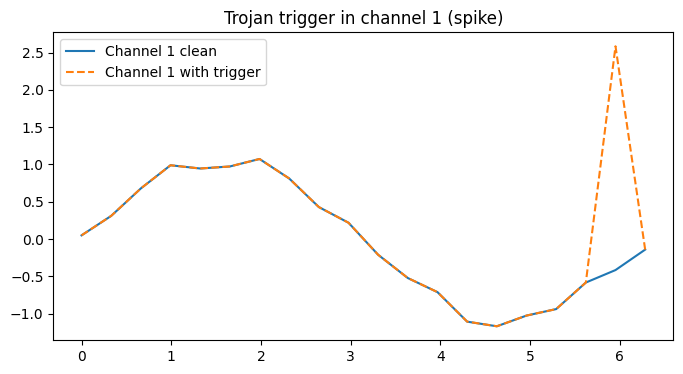

In [12]:
# ---------------------------
# 6. Visualize one trigger example
# ---------------------------
plt.figure(figsize=(8,4))
plt.title("Trojan trigger in channel 1 (spike)")
plt.plot(time, X_clean[0][:20], label="Channel 1 clean")
plt.plot(time, add_trigger(X_clean[0])[:20], label="Channel 1 with trigger", linestyle="--")
plt.legend()
plt.show()